In [1]:
import kenpom_model_api
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFE
from scipy.stats import chi2_contingency

from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.linear_model import SGDClassifier, Perceptron, LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

data = kenpom_model_api.load_data()

In [2]:
X = data.drop(columns=['Tourney'])
y = data['Tourney']

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                    test_size=0.3, random_state=42)
model = LogisticRegression(max_iter=10000, solver='liblinear')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.91


In [3]:
# Coefficients and Odds Ratios
coefficients = model.coef_[0]
odds_ratios = np.exp(coefficients)


# Display feature importance using coefficients and odds ratios
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Odds Ratio': odds_ratios
})
print("\nFeature Importance (Coefficient and Odds Ratio):")
print(feature_importance.sort_values(by='Coefficient', ascending=False))


Feature Importance (Coefficient and Odds Ratio):
          Feature  Coefficient   Odds Ratio
8            Luck     7.013483  1111.519702
40     Continuity     0.646030     1.907951
10           SOSO     0.634820     1.886683
13        APL_Off     0.533919     1.705603
0           AdjEM     0.470951     1.601516
17        eFG_Pct     0.360101     1.433475
6           Tempo     0.346940     1.414733
25          OffFt     0.343996     1.410573
46        NSTRate     0.280263     1.323477
5              DE     0.266106     1.304874
16    ConfAPL_Def     0.228492     1.256704
51      OppFG2Pct     0.190670     1.210061
27         OffFg3     0.183036     1.200857
50      OppFG3Pct     0.171740     1.187369
30         DefFg3     0.157387     1.170448
28          DefFt     0.155447     1.168180
49     Avg2PADist     0.151109     1.163123
23        DOR_Pct     0.127116     1.135549
2           AdjOE     0.121996     1.129750
29         DefFg2     0.121053     1.128685
36           Hgt2     0.11

In [4]:
# Permutation Importance
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)
perm_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance Mean': perm_importance.importances_mean,
    'Importance Std': perm_importance.importances_std
})
print("\nPermutation Importance:")
print(perm_importance_df.sort_values(by='Importance Mean', ascending=False))


Permutation Importance:
          Feature  Importance Mean  Importance Std
0           AdjEM         0.347670        0.007981
9             SOS         0.179961        0.006098
11           SOSD         0.141613        0.006483
10           SOSO         0.128810        0.007183
4           AdjDE         0.118859        0.007056
5              DE         0.049656        0.005399
6           Tempo         0.043913        0.005201
17        eFG_Pct         0.040747        0.004824
27         OffFg3         0.034356        0.005140
3              OE         0.032665        0.004315
48        F3GRate         0.031013        0.004687
2           AdjOE         0.029223        0.004957
25          OffFt         0.023756        0.005181
30         DefFg3         0.020000        0.003275
13        APL_Off         0.019469        0.003520
51      OppFG2Pct         0.017896        0.003723
1          Pythag         0.016401        0.002765
21       DeFG_Pct         0.015811        0.003985
41    

In [5]:
# Recursive Feature Elimination (RFE)
rfe_model = LogisticRegression()
rfe = RFE(rfe_model, n_features_to_select=10)
rfe.fit(X_train, y_train)


rfe_features = X.columns[rfe.support_]
print("\nSelected Features by RFE:")
print(rfe_features)


Selected Features by RFE:
Index(['AdjEM', 'Tempo', 'AdjTempo', 'Luck', 'SOS', 'NCSOS', 'ConfAPL_Off',
       'TO_Pct', 'FT_Rate', 'NSTRate'],
      dtype='object')


In [6]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif, RFE, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy # Requires: pip install boruta

# 1. SETUP - Aiming for top 10 features across all methods
n_select = 10
votes = pd.DataFrame({'Feature': X.columns})

# 2. FILTER METHODS (Statistical)
# ANOVA F-Value
skb = SelectKBest(f_classif, k=n_select).fit(X, y)
votes['SelectKBest'] = skb.get_support()

# Mutual Information (Captures non-linear dependencies)
mi = SelectKBest(mutual_info_classif, k=n_select).fit(X, y)
votes['Mutual_Info'] = mi.get_support()

# 3. WRAPPER METHODS (Iterative)
# RFE with Logistic Regression
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=n_select).fit(X, y)
votes['RFE'] = rfe.support_

# Boruta (Proves features are better than random shadow noise)
rf_boruta = RandomForestClassifier(n_jobs=-1, max_depth=5)
boruta = BorutaPy(rf_boruta, n_estimators='auto', verbose=0).fit(X.values, y.values)
votes['Boruta'] = boruta.support_

# 4. EMBEDDED METHODS (Model-Specific)
# Lasso (L1 Regularization - forces weak coefficients to zero)
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.2).fit(X, y)
lasso_top = np.argsort(abs(lasso.coef_[0]))[-n_select:]
votes['Lasso_L1'] = [i in lasso_top for i in range(len(X.columns))]

# Random Forest Importance (Tree-based impurity reduction)
rf = RandomForestClassifier(n_estimators=100).fit(X, y)
rf_top = np.argsort(rf.feature_importances_)[-n_select:]
votes['RandomForest'] = [i in rf_top for i in range(len(X.columns))]

# 5. FINAL TALLY
votes['Total_Votes'] = votes.iloc[:, 1:].sum(axis=1)
# Filter for features selected by at least 3 methods
consensus_features = votes[votes['Total_Votes'] >= 3].sort_values(by='Total_Votes', ascending=False)

print(consensus_features)

      Feature  SelectKBest  Mutual_Info    RFE  Boruta  Lasso_L1  \
0       AdjEM         True         True   True    True      True   
9         SOS         True         True   True    True      True   
1      Pythag         True         True   True    True     False   
5          DE         True         True   True    True     False   
3          OE         True         True   True    True     False   
2       AdjOE         True         True  False    True     False   
4       AdjDE         True         True  False    True     False   
8        Luck        False        False   True    True      True   
11       SOSD        False         True   True    True     False   
21   DeFG_Pct         True         True  False    True     False   
51  OppFG2Pct         True         True  False    True     False   

    RandomForest  Total_Votes  
0           True            6  
9           True            6  
1           True            5  
5           True            5  
3           True       

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Isolate the Consensus Features
# Assuming 'consensus_features' is the list of names from the previous step
X_final = X[consensus_features['Feature']]

# 2. Re-split and Scale
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Fit the Final Model
final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_train_scaled, y_train)

# 4. Generate Predictions
y_pred = final_model.predict(X_test_scaled)
y_proba = final_model.predict_proba(X_test_scaled)[:, 1] # Probability of being a '1' (In Tourney)

# 5. Print Metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      1064
        True       0.83      0.79      0.81       349

    accuracy                           0.91      1413
   macro avg       0.88      0.87      0.87      1413
weighted avg       0.91      0.91      0.91      1413

ROC-AUC Score: 0.9526


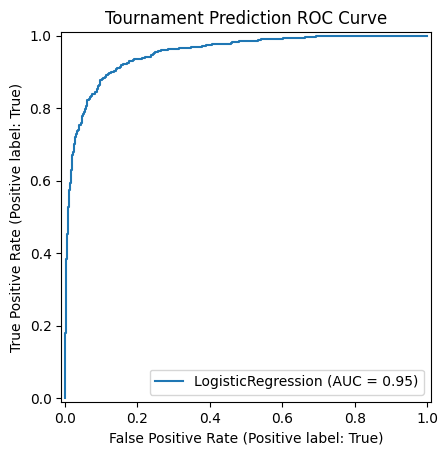

In [8]:
RocCurveDisplay.from_estimator(final_model, X_test_scaled, y_test)
plt.title("Tournament Prediction ROC Curve")
plt.show()

In [ ]:
import time
def get_classifier_best(Classifier, X, y, tune=None, **params):
    print('Training classifier \'{}\'...'.format(Classifier.__name__))
    start_time = time.time()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=13, shuffle=True)
    clf = Classifier(**params)
    best_score = 0

    if tune:
        search = GridSearchCV(clf, tune, refit=True, n_jobs=-1)
        search.fit(X_train, y_train)

        best_params = search.best_params_
        best_score = search.best_score_
        print('{} scores: {}\twith {}'.format(Classifier.__name__, best_score, best_params))
        clf = search.best_estimator_
    else:
        cv_results = cross_validate(clf, X, y, cv=5)
        scores = cv_results['test_score']
        best_score = np.mean(scores)
        print('{} scores: {} ± {}'.format(Classifier.__name__, best_score, np.std(scores)))

        clf.fit(X_train, y_train)
    if hasattr(clf, 'feature_importances_') and hasattr(clf, 'feature_names_in_'):
        importances = sorted(zip(clf.feature_names_in_, clf.feature_importances_), key=lambda x: x[1], reverse=True)
        print('Feature Importances: {}'.format(importances))
    duration = time.time() - start_time
    print(f"⏱️ {clf.__name__} took {duration:.2f} seconds")
    return clf, best_score

In [ ]:

# run ML models
models = []

tune_params = [{'strategy': ['uniform'], 'random_state': [13]}]
result = get_classifier_best(DummyClassifier, X, y, tune=None, strategy='uniform')
models.append(result)

tune_params = [{'fit_intercept': [True, False], 'positive': [True, False]}]
result = get_classifier_best(LinearRegression, X, y, tune=tune_params)
models.append(result)

print()
tune_params = [{'learning_rate': [0.01,0.05,0.1,0.15], 'n_estimators': [50,100,200]}]
result = get_classifier_best(GradientBoostingClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {'C': [0.01, 0.1, 1.0, 2.0, 10.0, 20.0], 'kernel': ['linear', 'poly', 'rbf', 'sigmoid']}
result = get_classifier_best(SVC, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {'loss': ['hinge','log_loss','modified_huber','squared_hinge'], 'alpha': [0.0001, 0.001], 
    'learning_rate': ['optimal'], 'max_iter': [100000]}
result = get_classifier_best(SGDClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {}
result = get_classifier_best(GaussianNB, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {}
result = get_classifier_best(Perceptron, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {'solver': ['lbfgs', 'adam'], 'batch_size': [16,32], 'hidden_layer_sizes': [(128), (128,64), (128,128,64), (512, 512, 128, 64)], 'max_iter': [10000]}
result = get_classifier_best(MLPClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {'n_estimators': [20,50,100,200], 'learning_rate': [0.01,0.1,0.5]}
result = get_classifier_best(AdaBoostClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {'n_neighbors': [3, 15, 25, 31], 'weights': ['uniform', 'distance'], 'p': [1, 2, 3]}
result = get_classifier_best(KNeighborsClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {'criterion': ['entropy', 'gini'], 'splitter': ['best', 'random']}
result = get_classifier_best(DecisionTreeClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {'n_estimators': [50, 100, 200], 'criterion': ['entropy', 'gini']}
result = get_classifier_best(RandomForestClassifier, X, y, tune=tune_params)
models.append(result)

print()
tune_params = {'max_iter_predict': [10, 100, 200]}
result = get_classifier_best(GaussianProcessClassifier, X, y, tune=tune_params)
models.append(result)

best_model, best_score = max(models, key=lambda x: x[1])
print('\nSelecting \'{}\' as best model with score: {}'.format(best_model.__class__.__name__, best_score))

Training classifier 'DummyClassifier'...
DummyClassifier scores: 0.5039781465311146 ± 0.018994439714250223
Training classifier 'LinearRegression'...
LinearRegression scores: 0.4843670030203132	with {'fit_intercept': False, 'positive': False}

Training classifier 'GradientBoostingClassifier'...
GradientBoostingClassifier scores: 0.9183177028803101	with {'learning_rate': 0.05, 'n_estimators': 200}
Feature Importances: [('AdjEM', np.float64(0.47822803493467253)), ('Pythag', np.float64(0.24239868478105395)), ('Luck', np.float64(0.08947721694535288)), ('OE', np.float64(0.032695500767428304)), ('DE', np.float64(0.02626171423275965)), ('SOS', np.float64(0.022415943979250817)), ('OppAvg2PADist', np.float64(0.013362018985154319)), ('Avg2PADist', np.float64(0.008773170663780406)), ('NCSOS', np.float64(0.007323536969250722)), ('AdjOE', np.float64(0.0052914459311100125)), ('FT_Rate', np.float64(0.005272527952573038)), ('SOSO', np.float64(0.005161647336986054)), ('OppFG2Pct', np.float64(0.004924762

ValueError: 
All the 40 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/envs/cbb-env/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/envs/cbb-env/lib/python3.11/site-packages/sklearn/base.py", line 1329, in wrapper
    estimator._validate_params()
  File "/opt/conda/envs/cbb-env/lib/python3.11/site-packages/sklearn/base.py", line 492, in _validate_params
    validate_parameter_constraints(
  File "/opt/conda/envs/cbb-env/lib/python3.11/site-packages/sklearn/utils/_param_validation.py", line 98, in validate_parameter_constraints
    raise InvalidParameterError(
sklearn.utils.